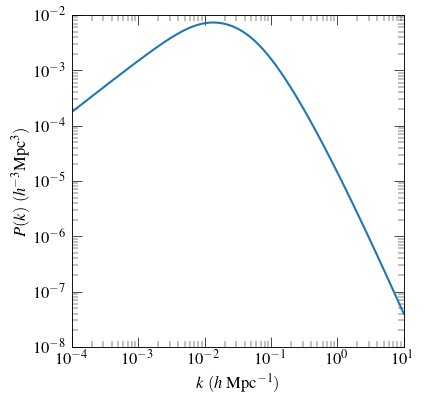

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')
plt.grid(visible=False)

# Define the cosmological parameters
Ohm_m = 0.26
Ohm_b = 0.0435
h = 0.71
n_s = 0.938

const_ps = 1.0

# Define the power spectrum function
def ps(k):
    Gamma = Ohm_m * h * np.exp(-Ohm_b - (2*h)**0.5 * Ohm_b/Ohm_m)
    q = k/Gamma
    tran_fun_a = np.log(1 + 2.34*q)/(2.34*q)
    tran_fun_b = (1 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4)**(-0.25)
    tran_fun = tran_fun_a * tran_fun_b
    
    return const_ps * k**n_s * tran_fun**2

# Define the k range
k = np.logspace(-4, 1, 1000)

# Plot the power spectrum
plt.plot(k, ps(k))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k ~ (h ~ \mathrm{Mpc}^{-1})$')
plt.ylabel(r'$P(k) ~ (h^{-3}\mathrm{Mpc}^3)$')
plt.ylim(1e-8, 1e-2)

# Make the plot box square
plt.gca().set_box_aspect(aspect=1)
# plt.xlim(0, 5)
# save the plot as a pdf file
plt.savefig(PLOT_DIRECTORY + 'power_spectrum_Bardeen.pdf')

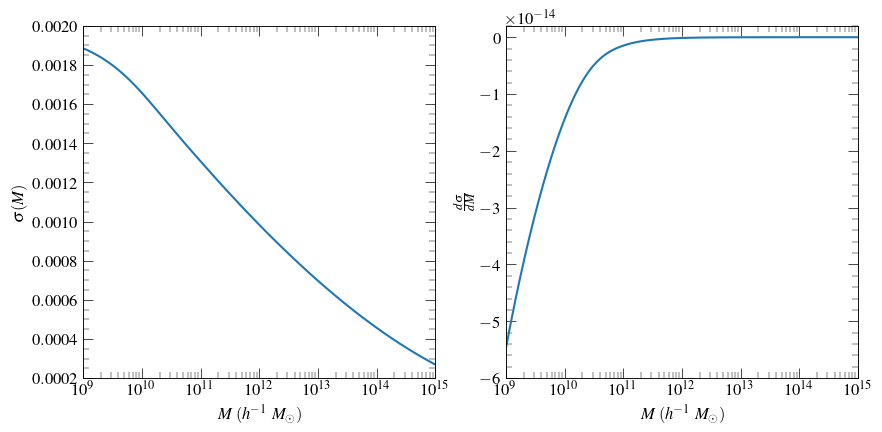

In [59]:
from scipy import integrate

# Define the mean density of the universe at z=0
rho_0 = 2.78e11 * Ohm_m # h^3 h^-1 M_sun/Mpc^3 unit

# Define the spherical top hat filter function
def W(kr):
    return 3*(np.sin(kr) - kr*np.cos(kr))/kr**3

# Define the masses where we want evaluate the halo mass function
M = np.logspace(9, 15, 1000) # h^-1 M_sun unit

# Define the rms linear density fluctuation at the present time smoothed by spherical top hat
def sigma(M):
    kr = k * ((3 * M)/(4 * np.pi * rho_0))**(1/3)
    return (integrate.simps(k**2 * ps(k) * W(kr)**2, k)/(2 * np.pi ** 2))**0.5
vec_sigma = np.vectorize(sigma)

dsigma_dM = np.gradient(vec_sigma(M), M)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot the rms linear density fluctuation
ax[0].plot(M, vec_sigma(M))
ax[0].set_xlabel(r'$M ~ (h^{-1} ~ M_{\odot})$')
ax[0].set_ylabel(r'$\sigma(M)$')
ax[0].set_xscale('log')
ax[0].grid(visible=False)
ax[0].set_box_aspect(aspect=1)
ax[0].set_ylim(0.0002, 0.0020)

ax[1].plot(M, dsigma_dM)
ax[1].set_xlabel(r'$M ~ (h^{-1} ~ M_{\odot})$')
ax[1].set_ylabel(r'$\frac{d\sigma}{dM}$')
ax[1].set_xscale('log')
ax[1].grid(visible=False)
ax[1].set_box_aspect(aspect=1)
ax[1].set_ylim(-6e-14, 0.2e-14)

# save the plot as a pdf file
plt.savefig(PLOT_DIRECTORY + 'sigma_dsigma_dM_Shen.pdf')

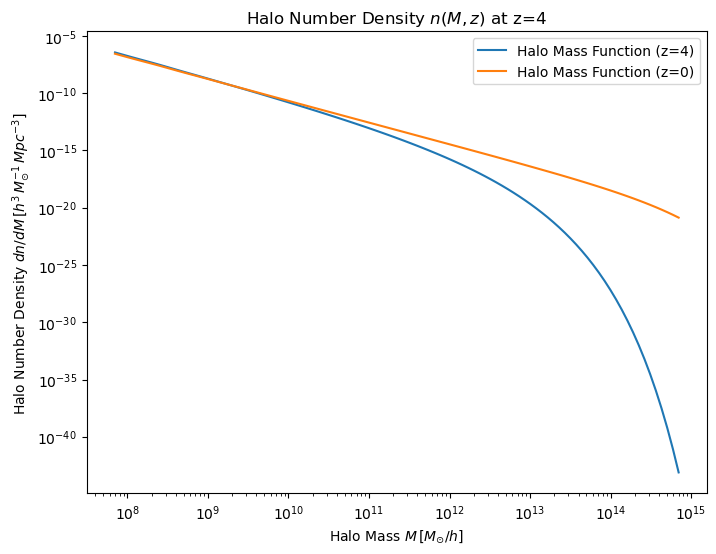

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# halo_mass_function.py copied from the link: https://github.com/sbird/DLA_script
from halo_mass_function import HaloMassFunction

# Parameters
redshift = 4  # You can change this to the desired redshift
mass_min = 1e8 * h  # Minimum halo mass in units of M_sun / h
mass_max = 1e15 * h  # Maximum halo mass in units of M_sun / h
num_masses = 100  # Number of points in the mass range
masses = np.logspace(np.log10(mass_min), np.log10(mass_max), num=num_masses)  # Log-spaced mass range

# Initialize the HaloMassFunction class
halo_mass_func = HaloMassFunction(redshift=redshift)
halo_mass_func2 = HaloMassFunction(redshift=0)

# Compute the Sheth-Tormen halo mass function dn/dM for each mass
dndm_values = np.array([halo_mass_func.dndm(mass) for mass in masses])
dndm_values2 = np.array([halo_mass_func2.dndm(mass) for mass in masses])

# Plot the mass function dn/dM
plt.figure(figsize=(8, 6))
plt.loglog(masses, dndm_values, label=f'Halo Mass Function (z={redshift})')
plt.loglog(masses, dndm_values2, label=f'Halo Mass Function (z=0)')
plt.xlabel(r'Halo Mass $M \, [M_{\odot} / h]$')
plt.ylabel(r'Halo Number Density $dn/dM \, [h^3 \, M_{\odot}^{-1} \, Mpc^{-3}]$')
plt.title(f'Halo Number Density $n(M, z)$ at z={redshift}')
plt.grid(False)
plt.legend()
plt.show()


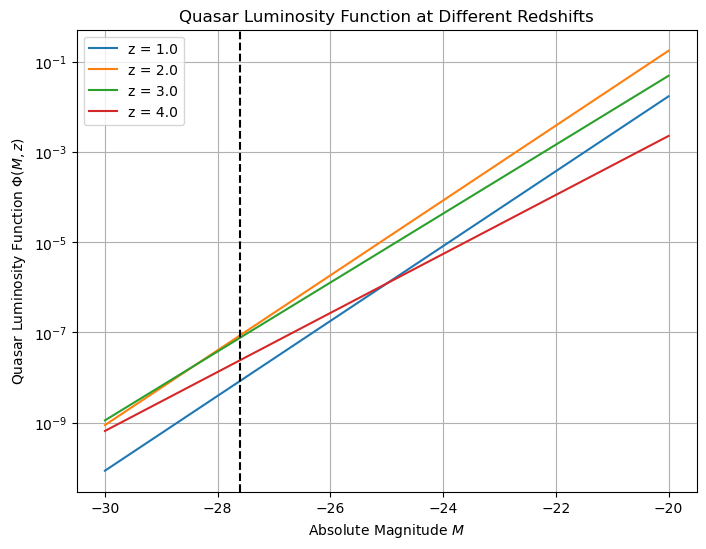

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the variable power law model
A1 = 0.83
A2 = -0.11
B1 = 1.43
B2 = 36.63
B3 = 34.39
M_star = -26
z_ref = 2.45
phi_star = 10 ** (-5.70)

def phi(M, z, M_star, B1, B2, B3):
    """Calculate the phi term in the QLF equation."""
    psi = np.log10((1 + z) / (1 + z_ref))
    return M - (M_star + B1 * psi + B2 * psi**2 + B3 * psi**3)

def quasar_luminosity_function(M, z):
    """Calculate the QLF for a given absolute magnitude M and redshift z."""
    if z <= 2.40:
        A = A1
    else:
        A = A1 + A2 * (z - 2.40)
    phi_value = phi(M, z, M_star, B1, B2, B3)
    return phi_star * 10 ** (A * phi_value)

# Define a range of magnitudes and redshifts
M_values = np.linspace(-30, -20, 100)  # Absolute magnitudes
z_values = [1.0, 2.0, 3.0, 4.0]        # Different redshifts

# Plot the QLF for different redshifts
plt.figure(figsize=(8, 6))
for z in z_values:
    phi_values = quasar_luminosity_function(M_values, z)
    plt.plot(M_values, phi_values, label=f'z = {z}')

plt.xlabel('Absolute Magnitude $M$')
plt.ylabel('Quasar Luminosity Function $\\Phi(M, z)$')
plt.title('Quasar Luminosity Function at Different Redshifts')
plt.axvline(x=-27.6, color='k', linestyle='--')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()


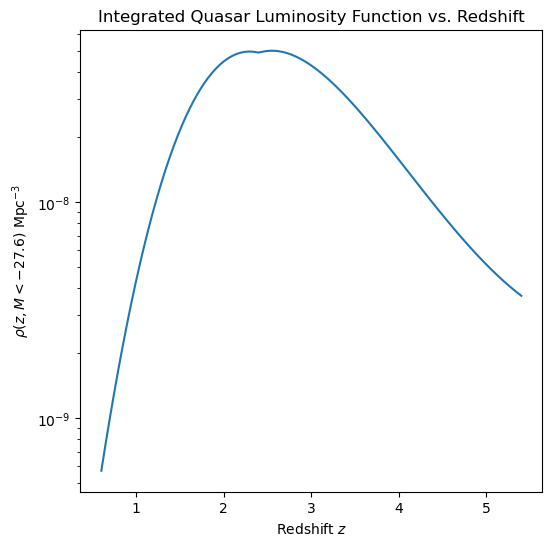

In [9]:
import numpy as np
import matplotlib.pyplot as plt

z_values = np.linspace(0.6, 5.4, 100) # Redshift values

# Integrate quasar luminosity function over the range of magnitudes -27.6 to -30
M_values = np.linspace(-30, -27.6, 100)
integral_values = [np.trapz(quasar_luminosity_function(M_values, z), M_values) for z in z_values]

# Plot the integrated QLF as a function of redshift
plt.figure(figsize=(8, 6))
plt.plot(z_values, integral_values)
plt.xlabel('Redshift $z$')
plt.ylabel(r'$\rho(z, M < -27.6)$ Mpc$^{-3}$')
plt.title('Integrated Quasar Luminosity Function vs. Redshift')
plt.grid(False)
plt.yscale('log')
plt.gca().set_box_aspect(1)
plt.show()

In [5]:
# Integral value corresponding to nearest z_value to 4.0
print(integral_values[np.abs(z_values - 4.0).argmin()])

1.4853571505550128e-08


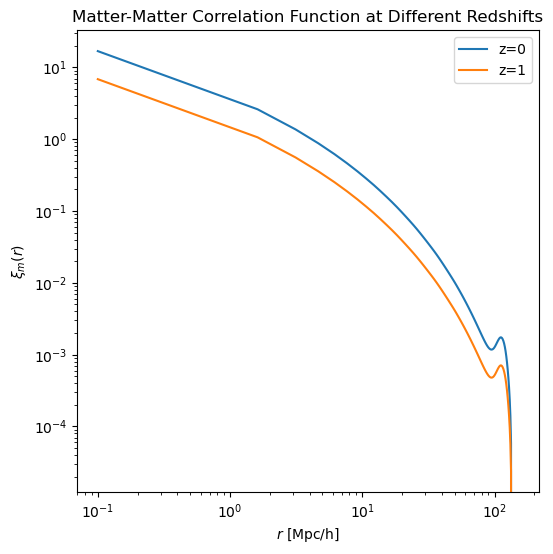

In [12]:
from colossus.cosmology import cosmology
import numpy as np
import matplotlib.pyplot as plt

# Define the cosmology
cosmo = cosmology.setCosmology('WMAP3')

# Define a function for the matter-matter correlation function at a given redshift
def xi_mm(r, z):
    return cosmo.correlationFunction(r, z)

# Plot the matter-matter correlation function at z=0 and z=1
r_values = np.linspace(0.1, 150, 100)  # Radial distances

plt.figure(figsize=(8, 6))
plt.plot(r_values, xi_mm(r_values, z=0), label='z=0')
plt.plot(r_values, xi_mm(r_values, z=1), label='z=1')
plt.xlabel('$r$ [Mpc/h]')
plt.ylabel(r'$\xi_m(r)$')
plt.title('Matter-Matter Correlation Function at Different Redshifts')
plt.gca().set_box_aspect(1)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

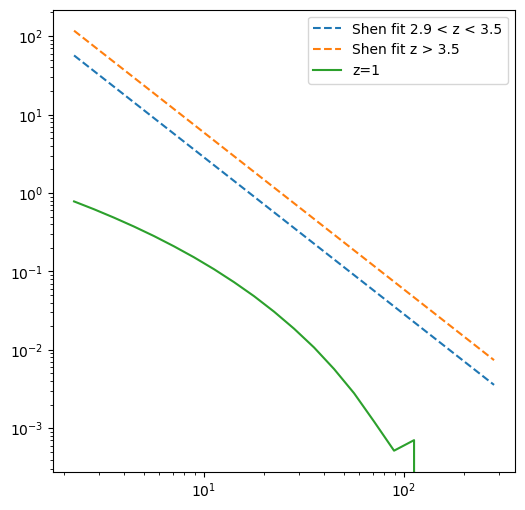

In [17]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt

r_bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23)
r_mid = (r_bins[:-1] + r_bins[1:])/2

# original = ma.masked_values([0, 0, 0, 16.5, 0, 3.54, 1.26, 0.663, 0.191, 0.131, 0.236, -0.280, 0.361, 0.101, 0.0384, 0.0368, 0.0101, 0.0194, -0.00396, 0.0101, -0.00296, 0.00214], 0)
# original_error = ma.masked_values([0, 0, 0, 12.8, 0, 3.61, 1.88, 0.733, 0.786, 0.472, 0.175, 0.223, 0.170, 0.121, 0.0862, 0.0644, 0.0382, \
#                                     0.0250, 0.0219, 0.0134, 0.00672, 0.00953], 0)

fit_clust2_9 = pow(r_mid/ 16.90, -2.0)
fit_clust3_5 = pow(r_mid/ 24.30, -2.0)

plt.figure(figsize=(8, 6))
plt.plot(r_mid, fit_clust2_9, '--', label="Shen fit 2.9 < z < 3.5")
plt.plot(r_mid, fit_clust3_5, '--', label="Shen fit z > 3.5")
# plt.errorbar(s_mid*np.power(10, 0.02), original, original_error, fmt='r*', capsize=5, label="Shen data")
plt.plot(r_mid, xi_mm(r_mid, z=1), label='z=1')
plt.xscale('log')
plt.yscale('log')
plt.gca().set_box_aspect(1)
plt.legend()

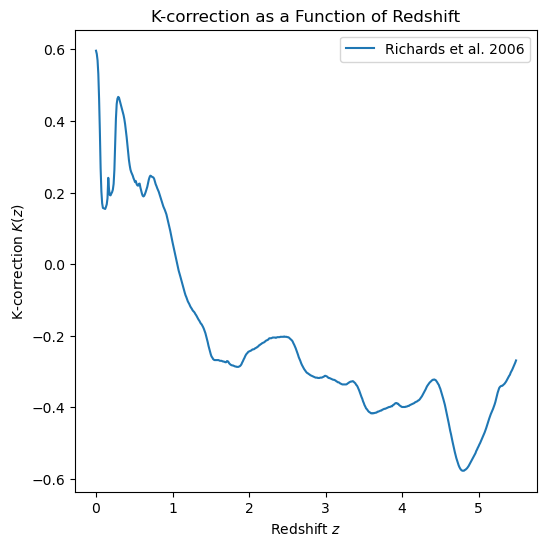

In [6]:
DATA_DIRECTORY2 = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data2.0/"

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii

# Load the K-correction file of Richards et al. 2006 Table 4 from the data2.0 folder. The file is in ASCII format.
data = ascii.read(DATA_DIRECTORY2 + 'richards2006_table4.txt')

# Make a plot of the K-correction as a function of redshift.
plt.figure(figsize=(8, 6))
plt.plot(data['z'], data['KCorr'], label='Richards et al. 2006')
plt.xlabel('Redshift $z$')
plt.ylabel('K-correction $K(z)$')
plt.title('K-correction as a Function of Redshift')
plt.gca().set_box_aspect(1)
plt.legend()
plt.grid(False)
plt.show()

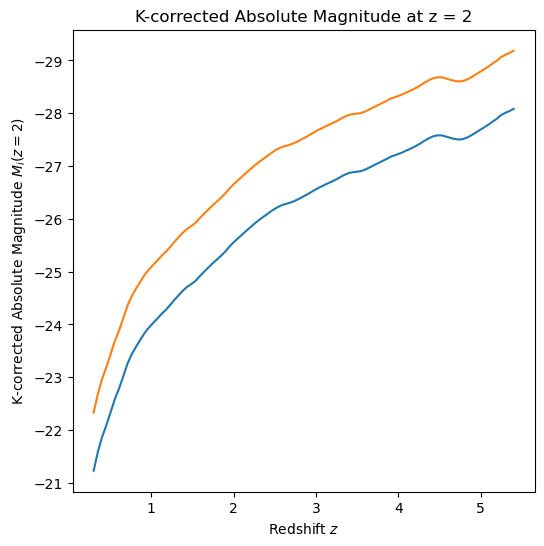

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import WMAP3 as cosmo

# Now we can convert the i band apparent magnitude of the survey to the absolute magnitude at z = 2 (M_i(z=2)). 

# Redshifts values under consideration.
z_values = np.linspace(0.3, 5.4, 100)

# Define the apparent magnitude limit of the survey
m_i = 20.2

# Absolute magnitude at z = z for the i band (M_i(z=z))
M_i = m_i - 5 * np.log10(1e6 * cosmo.luminosity_distance(z_values).value / 10)

# K-corrected absolute magnitude at z = 2 (M_i(z=2))
M_i_z2_20_2 = M_i - data['KCorr'][[np.abs(data['z'] - z).argmin() for z in z_values]]

# Same thing for magnitude 19.1
M_i_z2_19_1 = M_i - data['KCorr'][[np.abs(data['z'] - z).argmin() for z in z_values]] - 20.2 + 19.1

# Plot the K-corrected absolute magnitude at z = 2
plt.figure(figsize=(8, 6))
plt.plot(z_values, M_i_z2_20_2, label='Apparent Magnitude Limit $m_i = 20.2$')
plt.plot(z_values, M_i_z2_19_1, label='Apparent Magnitude Limit $m_i = 19.1$')
plt.xlabel('Redshift $z$')
plt.ylabel('K-corrected Absolute Magnitude $M_i(z=2)$')
plt.title('K-corrected Absolute Magnitude at z = 2')
plt.gca().set_box_aspect(1)
plt.grid(False)

# Invert the y axis
plt.gca().invert_yaxis()

plt.show()

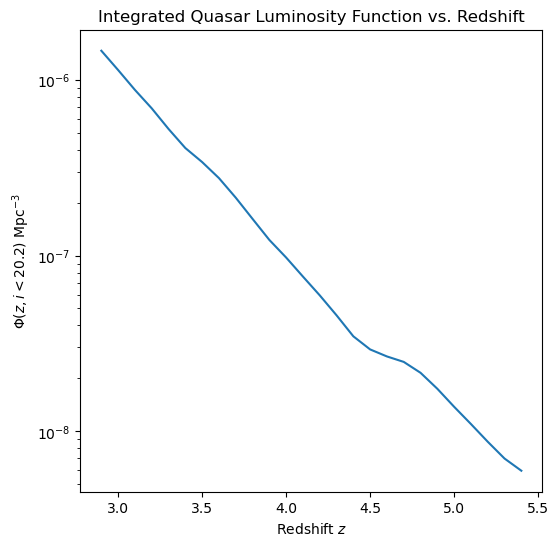

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import WMAP3 as cosmo
from astropy.cosmology import LambdaCDM

# Define the richards cosmology 
cosmo_richards = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

h = cosmo.h

# Parameters for the variable power law model
A1 = 0.83
A2 = -0.11
B1 = 1.43
B2 = 36.63
B3 = 34.39
M_star = -26
z_ref = 2.45
phi_star = 10 ** (-5.70)

def phi(M, z, M_star, B1, B2, B3):
    """Calculate the phi term in the QLF equation."""
    psi = np.log10((1 + z) / (1 + z_ref))
    return M - (M_star + B1 * psi + B2 * psi**2 + B3 * psi**3)

def quasar_luminosity_function(M, z):
    """Calculate the QLF for a given absolute magnitude M and redshift z."""
    if z <= 2.40:
        A = A1
    else:
        A = A1 + A2 * (z - 2.40)
    phi_value = phi(M, z, M_star, B1, B2, B3)
    return phi_star * 10 ** (A * phi_value)

# Define a range of magnitudes and redshifts
# M_values = np.linspace(-30, -20, 100)  # Absolute magnitudes
# z_values = [1.0, 2.0, 3.0, 4.0]        # Different redshifts

# # Plot the QLF for different redshifts
# plt.figure(figsize=(8, 6))
# for z in z_values:
#     phi_values = quasar_luminosity_function(M_values, z)
#     plt.plot(M_values, phi_values, label=f'z = {z}')

# plt.xlabel('Absolute Magnitude $M$')
# plt.ylabel('Quasar Luminosity Function $\\Phi(M, z)$')
# plt.title('Quasar Luminosity Function at Different Redshifts')
# plt.axvline(x=-27.6, color='k', linestyle='--')
# plt.legend()
# plt.yscale('log')
# plt.grid(True)
# # plt.show()

z_values = np.arange(2.9, 5.4, 0.1) # Redshift values
M_values = np.linspace(-35, -21, 1000)  # Absolute magnitudes

# Integrate quasar luminosity function down to magnitude cut of i = 20.2
# For this we find the integration absolute magnitude limit for each redshift
M_bright = -30
M_faint = m_i - 5 * np.log10(1e6 * cosmo.luminosity_distance(z_values).value * h / 10) \
            - data['KCorr'][[np.abs(data['z'] - z).argmin() for z in z_values]]

# Integrate the QLF over the range of magnitudes
integral_values = [np.trapz(quasar_luminosity_function(M_values, z)[M_values <= M_faint[i]], M_values[M_values <= M_faint[i]]) for i, z in enumerate(z_values)]

# Find the ratio of comoving volume elements for the two cosmologies
com_vol_ratio = (cosmo.angular_diameter_distance(z_values).value**2 / cosmo_richards.angular_diameter_distance(z_values).value**2) * \
                    (cosmo_richards.H(z_values).value / cosmo.H(z_values).value)

# Multiply the integrated QLF by the comoving volume ratio
integral_values = integral_values * com_vol_ratio

# Plot the integrated QLF as a function of redshift
plt.figure(figsize=(8, 6))
plt.plot(z_values, integral_values)
plt.xlabel('Redshift $z$')
plt.ylabel(r'$\Phi(z, i < 20.2)$ Mpc$^{-3}$')
plt.title('Integrated Quasar Luminosity Function vs. Redshift')
plt.grid(False)
plt.yscale('log')
plt.gca().set_box_aspect(1)
plt.show()


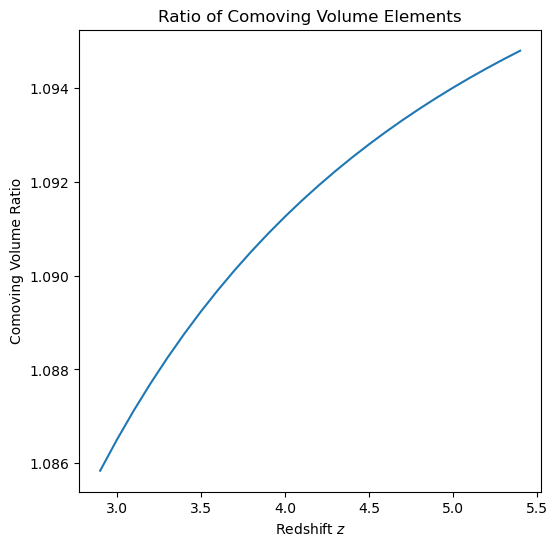

In [9]:
from astropy.cosmology import LambdaCDM

# Define the richards cosmology 
cosmo_richards = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Find the ratio of comoving volume elements for the two cosmologies
com_vol_ratio = (cosmo.angular_diameter_distance(z_values).value**2 / cosmo_richards.angular_diameter_distance(z_values).value**2) * \
                    (cosmo_richards.H(z_values).value / cosmo.H(z_values).value)

# Plot the ratio of comoving volume elements
plt.figure(figsize=(8, 6))
plt.plot(z_values, com_vol_ratio)
plt.xlabel('Redshift $z$')
plt.ylabel('Comoving Volume Ratio')
plt.title('Ratio of Comoving Volume Elements')
plt.grid(False)
plt.gca().set_box_aspect(1)
plt.show()


Quasar number density at z=2.0: 2.0328e-15 Mpc^-3


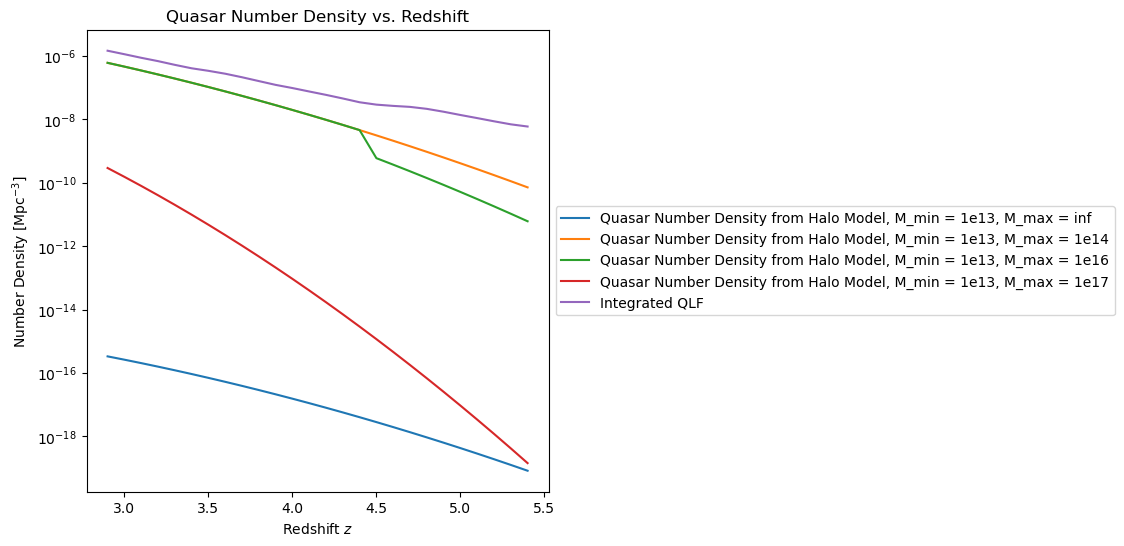

In [55]:
import numpy as np
from scipy.integrate import quad

# halo_mass_function.py copied from the link: https://github.com/sbird/DLA_script
from halo_mass_function import HaloMassFunction

# Define the redshift 
z = 2.0

def quasar_density(z, f_duty, M_min):
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the quasar number density with given duty cycle and minimum mass."""
    integral, _ = quad(lambda M: halo_mass_func.dndm(M), M_min, np.inf)
    return f_duty * integral

def quasar_density2(z, f_duty, M_min):
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the quasar number density with given duty cycle and minimum mass."""
    integral, _ = quad(lambda M: halo_mass_func.dndm(M), M_min, 1e14 * h)
    return f_duty * integral

def quasar_density3(z, f_duty, M_min):
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the quasar number density with given duty cycle and minimum mass."""
    integral, _ = quad(lambda M: halo_mass_func.dndm(M), M_min, 1e16 * h)
    return f_duty * integral

def quasar_density4(z, f_duty, M_min):
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the quasar number density with given duty cycle and minimum mass."""
    integral, _ = quad(lambda M: halo_mass_func.dndm(M), M_min, 1e17 * h)
    return f_duty * integral

# Example parameters
z = 2.0  # Example redshift
f_duty = 0.1  # Example duty cycle (fraction of halos hosting quasars)
M_min = 1e13 * h  # Minimum mass in solar masses/h

# Calculate quasar number density
n_Q = quasar_density(z, f_duty, M_min)
print(f"Quasar number density at z={z}: {n_Q:.4e} Mpc^-3")

# Show how quasar number density changes with redshift
z_values = np.arange(2.9, 5.4, 0.1)

n_Q_values = [quasar_density(z, f_duty, M_min) for z in z_values]
n_0_values2 = [quasar_density2(z, f_duty, M_min) for z in z_values]
n_0_values3 = [quasar_density3(z, f_duty, M_min) for z in z_values]
n_0_values4 = [quasar_density4(z, f_duty, M_min) for z in z_values]

# plt.figure(figsize=(8, 6))
# plt.plot(z_values, n_Q_values)
# plt.xlabel('Redshift $z$')
# plt.ylabel('Quasar Number Density $n_Q$ [Mpc$^{-3}$]')
# plt.title('Quasar Number Density vs. Redshift')
# plt.grid(False)
# plt.gca().set_box_aspect(1)
# plt.show()

# Plot this quasar number density evolution along with the integrated QLF
plt.figure(figsize=(8, 6))
plt.plot(z_values, n_Q_values, label='Quasar Number Density from Halo Model, M_min = 1e13, M_max = inf')
plt.plot(z_values, n_0_values2, label='Quasar Number Density from Halo Model, M_min = 1e13, M_max = 1e14')
plt.plot(z_values, n_0_values3, label='Quasar Number Density from Halo Model, M_min = 1e13, M_max = 1e16')
plt.plot(z_values, n_0_values4, label='Quasar Number Density from Halo Model, M_min = 1e13, M_max = 1e17')
plt.plot(z_values, integral_values, label='Integrated QLF')
plt.xlabel('Redshift $z$')
plt.ylabel('Number Density [Mpc$^{-3}$]')
plt.title('Quasar Number Density vs. Redshift')
plt.grid(False)
# Put legends outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gca().set_box_aspect(1)
plt.yscale('log')
plt.show()


Quasar number density at z=2.0: 5.0893e-06 Mpc^-3


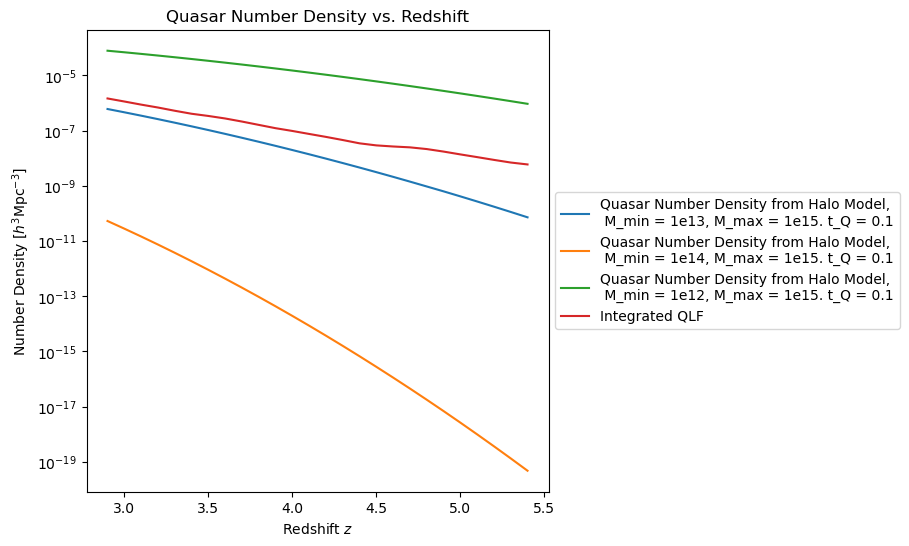

In [72]:
import numpy as np
from scipy.integrate import quad

# halo_mass_function.py copied from the link: https://github.com/sbird/DLA_script
from halo_mass_function import HaloMassFunction

# Define the redshift 
z = 2.0

def quasar_density(z, f_duty, M_min):
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the quasar number density with given duty cycle and minimum mass."""
    integral, _ = quad(lambda M: halo_mass_func.dndm(M), M_min, 1e15 * h)
    return f_duty * integral

# Example parameters
z = 2.0  # Example redshift
f_duty = 0.1  # Example duty cycle (fraction of halos hosting quasars)
M_min = 1e13 * h  # Minimum mass in solar masses/h

# Calculate quasar number density
n_Q = quasar_density(z, f_duty, M_min)
print(f"Quasar number density at z={z}: {n_Q:.4e} Mpc^-3")

# Show how quasar number density changes with redshift
z_values = np.arange(2.9, 5.4, 0.1)

n_Q_values = [quasar_density(z, f_duty, M_min) for z in z_values]
n_Q_values2 = [quasar_density(z, f_duty, 1e14 * h) for z in z_values]
n_Q_values3 = [quasar_density(z, f_duty, 1e12 * h) for z in z_values]

# plt.figure(figsize=(8, 6))
# plt.plot(z_values, n_Q_values)
# plt.xlabel('Redshift $z$')
# plt.ylabel('Quasar Number Density $n_Q$ [Mpc$^{-3}$]')
# plt.title('Quasar Number Density vs. Redshift')
# plt.grid(False)
# plt.gca().set_box_aspect(1)
# plt.show()

# Plot this quasar number density evolution along with the integrated QLF
plt.figure(figsize=(8, 6))
plt.plot(z_values, n_Q_values, label='Quasar Number Density from Halo Model, \n M_min = 1e13, M_max = 1e15. t_Q = 0.1')
plt.plot(z_values, n_Q_values2, label='Quasar Number Density from Halo Model, \n M_min = 1e14, M_max = 1e15. t_Q = 0.1')
plt.plot(z_values, n_Q_values3, label='Quasar Number Density from Halo Model, \n M_min = 1e12, M_max = 1e15. t_Q = 0.1')
plt.plot(z_values, integral_values, label='Integrated QLF')
plt.xlabel('Redshift $z$')
plt.ylabel('Number Density [$h^3$Mpc$^{-3}$]')
plt.title('Quasar Number Density vs. Redshift')
plt.grid(False)
# Put legends outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gca().set_box_aspect(1)
plt.yscale('log')
plt.show()


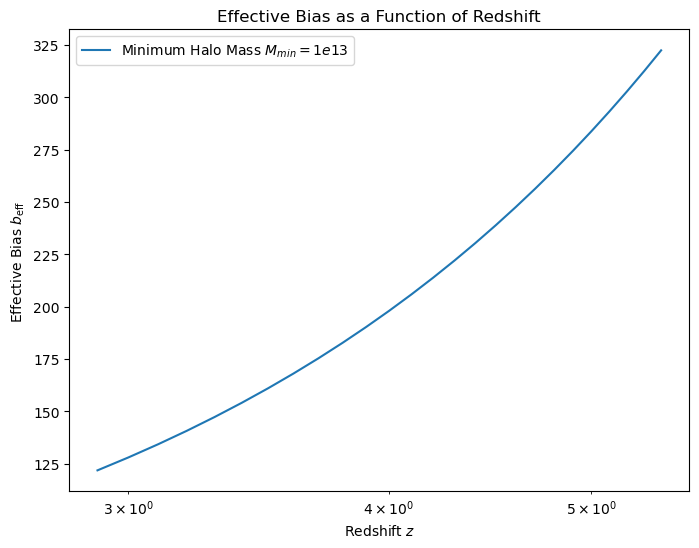

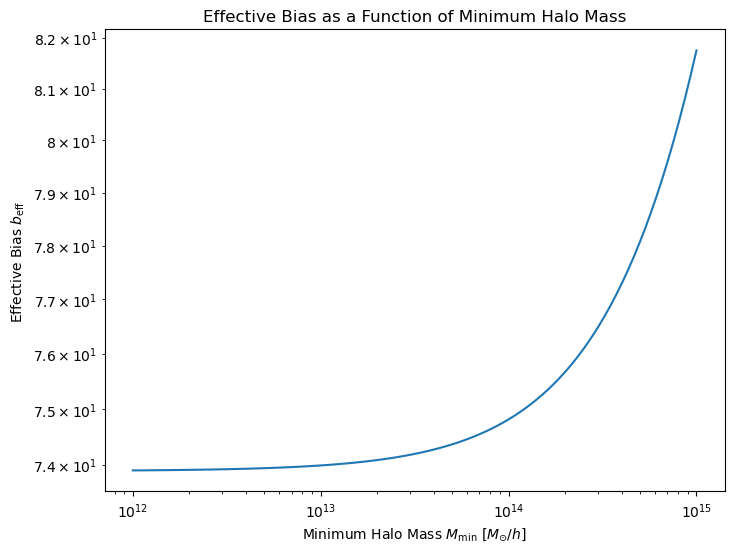

In [78]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from colossus.lss import bias


from colossus.cosmology import cosmology
cosmology.setCosmology('WMAP3');

def halo_bias(M, z):
    return bias.haloBias(M, model = 'jing98', z = z, mdef = 'vir')

def effective_bias(M_min, z):
    M_max = 1e16 * h
    halo_mass_func = HaloMassFunction(redshift=z, omega_m=0.26, omega_l=0.74, hubble=0.71)
    """Calculate the effective bias as a function of M_min and redshift z."""
    # Numerator: Integrate halo_bias * halo_mass_function over M from M_min to infinity
    numerator = quad(lambda M: halo_bias(M, z) * halo_mass_func.dndm(z), M_min, M_max)[0]

    # Denominator: Integrate halo_mass_function over M from M_min to infinity
    denominator = quad(lambda M: halo_mass_func.dndm(z), M_min, M_max)[0]

    return numerator / denominator

# Plot the effective bias as a function of M_min
z_values = np.arange(2.9, 5.4, 0.1)
M_min = 1e12 * h  # Minimum halo masses in units of M_sun / h
bias_values = [effective_bias(M_min, z) for z in z_values]

plt.figure(figsize=(8, 6))
plt.plot(z_values, bias_values, label=f'Minimum Halo Mass $M_{{min}} = 1e13$')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Redshift $z$')
plt.ylabel(r'Effective Bias $b_{\mathrm{eff}}$')
plt.title('Effective Bias as a Function of Redshift')
plt.grid(False)
plt.legend()
plt.show()

# Plot the effective bias as a function of M_min
M_min_values = np.logspace(12, 15, 100)
bias_values2 = [effective_bias(M_min, z) for M_min in M_min_values]

plt.figure(figsize=(8, 6))
plt.plot(M_min_values, bias_values2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Minimum Halo Mass $M_{\mathrm{min}}$ [$M_{\odot} / h$]')
plt.ylabel(r'Effective Bias $b_{\mathrm{eff}}$')
plt.title('Effective Bias as a Function of Minimum Halo Mass')
plt.grid(False)
plt.show()
